<center><h1>Detected Exoplanets</center>

Rank | Name | Input Catalog | Orbital Period | Exoplanet Radius | Orbital Distance | Habitable Zone? |
| :- | :- | :- | -: | -: |-: | -: |
|Max Radius| BD-14 3065 b | TIC 293607057 | 4.29 d| 20.44 R🜨| 0.058 AU | too hot|
|Min Radius| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R🜨| 0.022 AU  |  too hot |
|Max Period| TOI-1836 b | TIC 207468071 | 20.38 d| 8.96 R🜨| 0.158 AU | too hot |
|Min Period| L 98-59 b | TIC 307210830 | 2.25 d| 0.91 R🜨| 0.022 AU  |  too hot |
|Max Exoplanets| TOI-270 b | TIC 259377017 | 3.36 d| 1.25 R🜨| 0.031 AU  |  too hot |
|Max Exoplanets| TOI-270 c | TIC 259377017 | 5.66 d| 2.34 R🜨| 0.044 AU | too hot |
|Max Exoplanets| TOI-270 d | TIC 259377017 | 11.38 d| 1.94 R🜨| 0.071 AU | too hot |

<center>gas giant > 6 R🜨 > neptunian > 4 R🜨 > sub-neptune > 2 R🜨 > super-earth > 1.5 R🜨 > terrestrial</center>

In [1]:
%matplotlib widget
import statistics
import matplotlib.pyplot as plt
import lightkurve as lk
import numpy as np
from scipy import stats
from scipy.optimize import least_squares
from astropy import units as u
from astropy import constants as const
from astroquery.mast import Catalogs
import batman

In [2]:
render_plots = True

In [3]:
input_catalog = input("input catalog: ")
split = input_catalog.split(" ")
telescope = split[0]

try:
    star = Catalogs.query_object(input_catalog, catalog = "TIC")
except:
    print("MAST import error: try again")

input catalog:  TIC 371443216


In [4]:
def import_tess(input_catalog, author):    
    all_data = lk.search_lightcurve(input_catalog, author = author, exptime = "short")
    print("all data:")
    print(all_data)
    
    sectors_list = []
    for sector in all_data.table:
        sectors_list.append(int(sector["sequence_number"]))

    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table["year"] >= yr_mode - 2) & (all_data.table["year"] <= yr_mode + 2)
        else:
            year_mask = (all_data.table["year"] >= yr_median - 2) & (all_data.table["year"] <= yr_median + 2)
                
        selected_data = all_data[year_mask]
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = "short", sector = sectors_list)[year_mask].download_all()
    else:
        selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = "short", limit = 5)
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = "short", sector = sectors_list).download_all()
        
    print("\nselected data:")
    print(selected_data)        
    return all_data, sectors_list, selected_data, stitch_me

def import_kepler(input_catalog, author):    
    all_data = lk.search_lightcurve(input_catalog, author = author, exptime = "short")
    print("all data:")
    print(all_data)
    
    quarters_list = []
    for quarter in all_data.table:
        quarters_list.append(int(quarter["mission"].split(" ")[2]))

    all_years = []
    for each in all_data:
        all_years.append(each.year.item())
    yr_max_i = np.max(range(len(all_years)))
    yr_max = (all_years[yr_max_i])
    yr_min = (all_years[0])
    yr_range = yr_max - yr_min

    if yr_range > 5:
        yr_count = np.bincount(all_years)
        yr_mode = round(np.argmax(yr_count))
        yr_median = round(np.median(all_years))

        if np.max(yr_count) > 5:
            year_mask = (all_data.table["year"] >= yr_mode - 1) & (all_data.table["year"] <= yr_mode + 1)
        else:
            year_mask = (all_data.table["year"] >= yr_median - 1) & (all_data.table["year"] <= yr_median + 1)
                
        selected_data = all_data[year_mask]
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = "short", quarter = quarters_list)[year_mask].download_all()
    else:
        selected_data = lk.search_lightcurve(input_catalog, author = author, exptime = "short", limit = 5)
        stitch_me = lk.search_lightcurve(input_catalog, author = author, exptime = "short", quarter = quarters_list).download_all()
        
    print("\nselected data:")
    print(selected_data)
    return all_data, quarters_list, selected_data, stitch_me

if telescope == "TIC":
    author = "SPOC"
    all_data, sectors, selected_data, stitch_me = import_tess(input_catalog, author)
if telescope == "KIC":
    author = "Kepler"
    all_data, quarters, selected_data, stitch_me = import_kepler(input_catalog, author)

all data:
SearchResult containing 4 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 36 2021   SPOC     120   371443216      0.0
  1 TESS Sector 38 2021   SPOC     120   371443216      0.0
  2 TESS Sector 63 2023   SPOC     120   371443216      0.0
  3 TESS Sector 90 2025   SPOC     120   371443216      0.0

selected data:
SearchResult containing 4 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 36 2021   SPOC     120   371443216      0.0
  1 TESS Sector 38 2021   SPOC     120   371443216      0.0
  2 TESS Sector 63 2023   SPOC     120   371443216      0.0
  3 TESS Sector 90 2025   SPOC     120   371443216      0.0


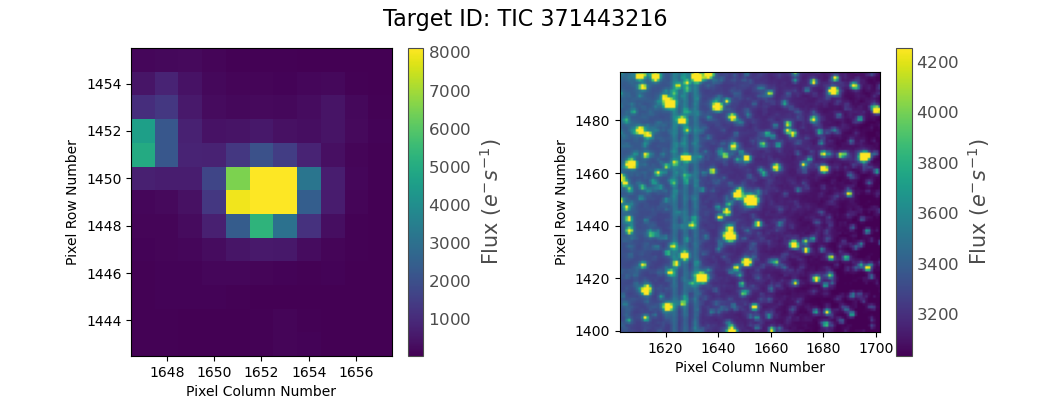

In [5]:
if render_plots == True:
    if telescope == "TIC":
        fig, (ax1, ax2) = plt.subplots(nrows = 1 ,ncols = 2, figsize = (10.5, 4))
        fig.suptitle(f"Target ID: {input_catalog}", fontsize = 16)
        fig.subplots_adjust(wspace = .5)
        
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = "short", sector = sectors[0]).download()
        px_file.plot(ax = ax1, title = "")
        
        ff_file = lk.search_tesscut(input_catalog, sector = sectors[0]).download(cutout_size = 99)
        ff_file.plot(ax = ax2, title = "")
        
    if telescope == "KIC":
        px_file = lk.search_targetpixelfile(input_catalog, author = author, exptime = "short", quarter = quarters[0]).download()
        px_file.plot()
        plt.title(f"Target ID: {input_catalog}", fontsize = 16)

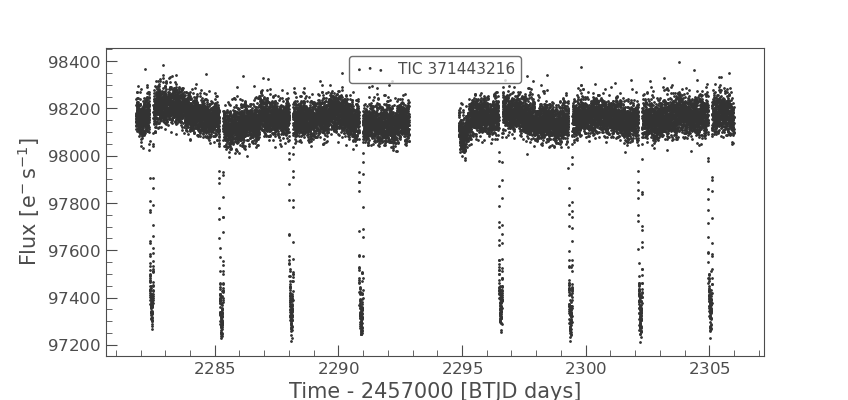

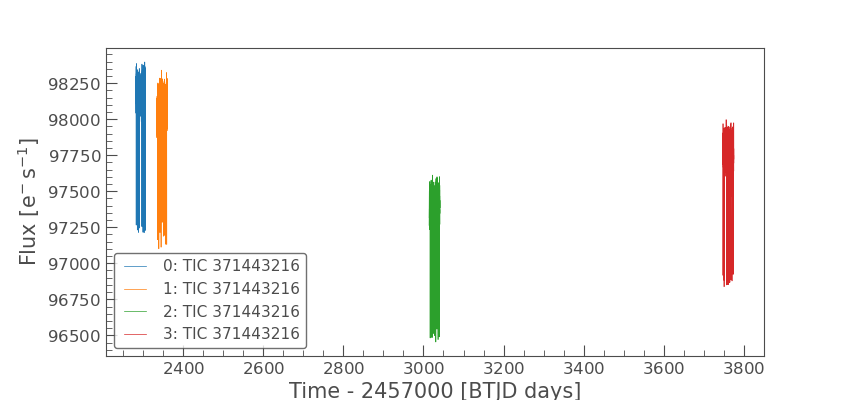

In [6]:
if telescope == "TIC":
    ts_first = lk.search_lightcurve(input_catalog, author = author, exptime = "short", sector = sectors[0], limit = 1).download()
    if len(sectors) > 1:
        bls_me = stitch_me.stitch().remove_nans().flatten()
    else:
        ts_first.scatter()
        bls_me = ts_first.remove_nans().flatten()

if telescope == "KIC":
    ts_first = lk.search_lightcurve(input_catalog, author = author, exptime = "short", quarter = quarters[0], limit = 1).download()
    if len(quarters) > 1:
        bls_me = stitch_me.stitch().remove_nans().flatten()
    else:
        ts_first.scatter()
        bls_me = ts_first.remove_nans().flatten()

if render_plots == True:
    ts_first.scatter()
    stitch_me.plot()

candidate 1 orbital period: 2.8241 days, SNR: 87.7012


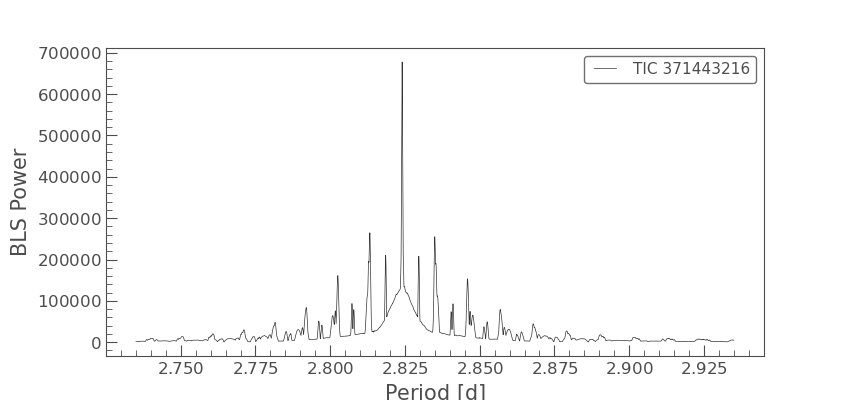

In [7]:
def initial_periodogram(bls_me, exclusions, i):
    search_duration = np.linspace(.05, .3, 10)
    search_period = np.logspace(np.log10(1), np.log10(21), 5000) 
    periodogram = bls_me.to_periodogram(method = "bls", period = search_period, duration = search_duration, frequency_factor = 1000)
    orbital_period = periodogram.period_at_max_power
    transit_time = periodogram.transit_time_at_max_power
    transit_duration = periodogram.duration_at_max_power  
    return periodogram, orbital_period, transit_time, transit_duration
    
def refine_periodogram(prev_bls_me, prev_period, prev_duration):
    duration = np.linspace(prev_duration.value - .01, prev_duration.value + .01, 10) 
    period = np.linspace(prev_period.value - .1, prev_period.value + .1, 5000)
    final_periodogram = prev_bls_me.to_periodogram(method = "bls", period = period, duration = duration)
    final_period = final_periodogram.period_at_max_power
    final_time = final_periodogram.transit_time_at_max_power
    final_duration = final_periodogram.duration_at_max_power
    return final_periodogram, final_period, final_time, final_duration
    
def detect_transit(prev_bls_me, prev_period, prev_time, prev_duration, periods):
    phased_lc = prev_bls_me.fold(period = prev_period, epoch_time = prev_time)
    transit_event = np.logical_and(phased_lc.phase > (-prev_duration/2), phased_lc.phase < (prev_duration/2))
    in_transit = np.median(phased_lc.flux[transit_event])
    out_transit = np.mean(phased_lc.flux[~transit_event])
    depth = out_transit - in_transit
    sigma = np.std(phased_lc.flux[~transit_event])*.2
    snr = depth/sigma
    
    if len(periods) > 1:
        i = 1
        while i < len(periods):
            multiple = periods[i]/periods[i-1]
            harmonics_test = round(multiple, 2) == round(multiple)
            i += 1
    else:
        harmonics_test = False
    
    if snr > 1.1 and harmonics_test == False:
        detected_transit = True
    else:
        detected_transit = False
    return detected_transit, phased_lc, snr

def next_function(prev_bls_me, prev_periodogram, prev_period, prev_time, prev_duration):
    mask = prev_periodogram.get_transit_mask(period = prev_period, transit_time = prev_time, duration = prev_duration)
    next_bls_me = prev_bls_me[~mask]
    exclude = (prev_periodogram.period < prev_period * .95) | (prev_periodogram.period > prev_period * 1.05) 
    prev_periodogram.power[~exclude] = 0
    return next_bls_me, exclude

candidates = [bls_me]
exclusions = []
exoplanets = []
potential_periods = []
periods = []
transit_times = []
durations = []

i = 0
potential_candidate = True
while potential_candidate:
    periodogram, orbital_period, transit_time, transit_duration = initial_periodogram(candidates[i], exclusions, i) 
    final_periodogram, final_period, final_time, final_duration = refine_periodogram(candidates[i], orbital_period, transit_duration)
    potential_periods.append(final_period.value)
    detected_transit, phased_lc, snr = detect_transit(candidates[i], final_period, final_time, final_duration, potential_periods)
    
    if detected_transit == True:
        print(f"candidate {i + 1} orbital period: {round(final_period.value, 4)} days, SNR: {round(snr, 4)}")
        exoplanets.append({"period": final_period, "t0": final_time, "duration": final_duration})  
        periods.append(final_period.value)
        transit_times.append(final_time.value)
        durations.append(final_duration.value)
        if render_plots == True:
            final_periodogram.plot()

        next_fold_me, exclude = next_function(candidates[i], final_periodogram, final_period, final_time, final_duration)
        candidates.append(next_fold_me)
        exclusions.append(exclude)  
    
        potential_candidate = True
    else:
        potential_candidate = False
    i += 1

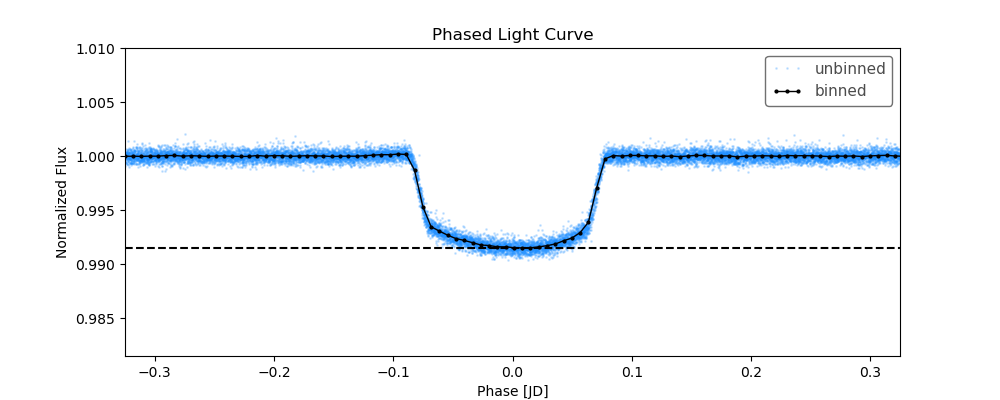

Radius:
18.4614 earthRad
1.647 jupiterRad


In [8]:
def clean_data(mission, bls_me):
    transit_mask = bls_me.create_transit_mask(
                period = periods, 
                transit_time = transit_times, 
                duration = durations
            )
    if len(mission) > 1:
        fold_me = stitch_me.stitch().remove_nans().flatten(mask = transit_mask)
    else:
        fold_me = ts_first.remove_nans().flatten(mask = transit_mask)
    return fold_me

def plot_light_curve(fold_me, period, t0, duration):
    phased_lc = fold_me.fold(period = period, epoch_time = t0)
    binned_lc = phased_lc.bin(10/60/24)
    dip = binned_lc.flux.value.min()
    depth = 1 - dip
    half_duration = duration.value/2
    if render_plots == True:
        fig, ax = plt.subplots(figsize = (10,4))
        phased_lc.plot(ax = ax, linewidth = '0', marker = ".", color = "dodgerblue", alpha = .2, label = "unbinned")
        binned_lc.plot(ax = ax, linewidth = '1', marker = "o", color = "black", label = "binned")
        plt.axhline(dip, color = 'black', linestyle = '--')
        plt.title("Phased Light Curve")
        plt.xlim(-(half_duration + .25), (half_duration + .25))
        plt.ylim(dip - .01, 1.01)
        plt.show()
    return depth, binned_lc

def estimate_radius(star, depth):
    exo_sun_rad = np.sqrt(depth) * (star["rad"][0] * u.R_sun)
    exo_earth_rad = exo_sun_rad.to(u.Rearth) 
    exo_jupiter_rad = exo_sun_rad.to(u.Rjupiter) 
    print('Radius:')
    print(round(exo_earth_rad, 4))
    print(round(exo_jupiter_rad, 4))
    return exo_earth_rad

if telescope == "TIC":
    fold_me = clean_data(sectors, bls_me)
if telescope == "KIC":
    fold_me = clean_data(quarters, bls_me)
    
for each in exoplanets:
    depth, binned_lc = plot_light_curve(fold_me, each["period"], each["t0"], each["duration"])
    each["depth"] = depth

    transit_event = np.logical_and(binned_lc.phase.value > -0.2, binned_lc.phase.value < 0.2)
    each["light_curve"] = binned_lc[transit_event]
    
    radius = estimate_radius(star, depth)
    each["radius"] = radius

In [9]:
def orbital_distance(star, period):
    star_mass = star["mass"][0]* u.M_sun
    star_mass = star_mass.to(u.kg)

    period = period.to(u.s)
    
    semimajor_axis = np.cbrt((const.G*star_mass*np.square(period))/(4*np.square(np.pi)))
    semimajor_axis = semimajor_axis.to(u.au)
    return semimajor_axis

def habitable_zone(star, semimajor_axis):
    star_luminosity = star["lum"][0]*u.L_sun

    inner_lim = np.sqrt(star_luminosity/(1.1*u.L_sun))*u.au
    outer_lim = np.sqrt(star_luminosity/(.53*u.L_sun))*u.au

    if semimajor_axis < inner_lim:
        habitability = "too hot"
    elif semimajor_axis > outer_lim:
        habitability = "too cold"
    else:
        habitability = "just right"
    return habitability

for each in exoplanets:
    semimajor_axis = orbital_distance(star, each["period"])
    each["semimajor_axis"] = semimajor_axis
    print(f"semi-major axis: {round(semimajor_axis, 4)}") 
    
    habitability = habitable_zone(star, each["semimajor_axis"])
    each["habitability"] = habitability
    print(f"habitable zone: {habitability}")  

semi-major axis: 0.0493 AU
habitable zone: too hot


radius: 17.271876272440615 earthRad
inclination: 86.43504515932398 deg
eccentricity: 8.708540970994561e-06
argument of periapsis (w): 89.9999999999862 deg


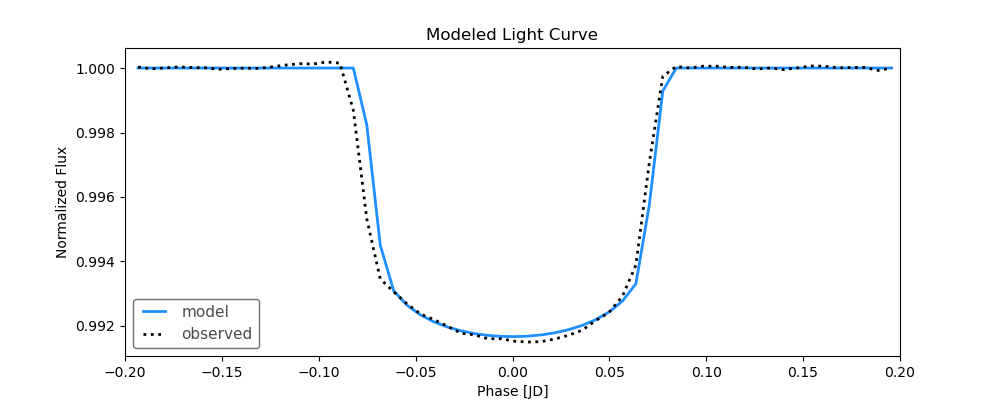

In [10]:
def initial_estimates(exoplanet, star):
    rad_est = (exoplanet["radius"].to(u.Rsun))/(star["rad"][0]*u.Rsun)
    inc_est = 90
    ecc_est = 0
    w_est = 90
    estimates = [rad_est, inc_est, ecc_est, w_est]
    lower_bounds = [rad_est-0.02,80,0,0]
    upper_bounds = [rad_est+0.02,90,0.999,180]
    return estimates, lower_bounds, upper_bounds
    
def batman_fun(x, exoplanet, star):
    params = batman.TransitParams()
    params.t0 = 0
    params.per = exoplanet["period"].value
    params.rp = x[0]
    params.a = (exoplanet["semimajor_axis"].to(u.Rsun))/(star["rad"][0]*u.Rsun)
    params.inc = x[1]
    params.ecc = x[2]
    params.w = x[3]
    params.limb_dark = "nonlinear"
    params.u = [0.5,0.1,0.1,-0.1]  
    
    phase_min = min(exoplanet["light_curve"].phase.value)
    phase_max = max(exoplanet["light_curve"].phase.value)
    phase_len = len(exoplanet["light_curve"].flux.value)
    time = np.linspace(phase_min, phase_max, phase_len)
                       
    model = batman.TransitModel(params,time)
    batman_flux = model.light_curve(params)
    return batman_flux

def calc_residuals(x, exoplanet, star):
    observed = exoplanet["light_curve"].flux.value
    observed_error = exoplanet["light_curve"].flux_err.value
    modeled = batman_fun(x, exoplanet, star)
    
    residuals = (observed-modeled)/observed_error
    return residuals

def plot_model(each, star):
    batman_flux = batman_fun(results.x, each, star)
    phase = each["light_curve"].phase.value

    fig, ax = plt.subplots(figsize = (10,4))
    ax.plot(phase, batman_flux, linewidth = '2', color = "dodgerblue", label = "model")
    each["light_curve"].plot(ax = ax, linewidth = '2', linestyle = ":", color = "black", label = "observed")
    plt.title("Modeled Light Curve")
    plt.xlim(-0.2,0.2)
    plt.show()

for each in exoplanets:
    estimates, lower_bounds, upper_bounds = initial_estimates(each, star)
    results = least_squares(calc_residuals, estimates, bounds = (lower_bounds, upper_bounds), args = (each, star,))

    each["radius"] = (results.x[0]*star["rad"][0]*u.Rsun).to(u.Rearth)
    each["inclination"] = results.x[1]*u.degree
    each["eccentricity"] = results.x[2]
    each["arg_periapsis"] = results.x[3]*u.degree
    print(f'radius: {each["radius"]}')
    print(f'inclination: {each["inclination"]}')
    print(f'eccentricity: {each["eccentricity"]}')
    print(f'argument of periapsis (w): {each["arg_periapsis"]}')

    plot_model(each, star)

In [11]:
for each in exoplanets:
    b1 = ((each["semimajor_axis"]*np.cos(each["inclination"].to(u.radian)))/((star["rad"][0]*u.Rsun).to(u.au)))
    b2 = ((1-np.square(each["eccentricity"]))/(1+(np.square(each["eccentricity"])*np.sin(each["arg_periapsis"].to(u.radian)))))

    each["impact_parameter"] = b1*b2
    print(f'impact parameter: {round(each["impact_parameter"],4)}')

impact parameter: 0.3587


In [12]:
exoplanets

[{'period': <Quantity 2.82406362 d>,
  't0': <Time object: scale='tdb' format='btjd' value=2282.4436996200843>,
  'duration': <Quantity 0.15 d>,
  'depth': np.float64(0.008497066207184711),
  'light_curve': <FoldedLightCurve length=57 LABEL="TIC 371443216" SECTOR=90 AUTHOR=SPOC FLUX_ORIGIN=pdcsap_flux>
          time                flux               flux_err        ...       pos_corr1             pos_corr2       
                                                                 ...          pix                   pix          
       TimeDelta            float64              float64         ...        float64               float64        
  -------------------- ------------------ ---------------------- ... --------------------- ----------------------
  -0.19325901066369577 1.0000304408423268 2.8718422075479492e-05 ... -0.010500315576791763  -0.007889428175985813
  -0.18631456621925135 0.9999768877504823  2.863567979262967e-05 ... -0.010318811982870102  -0.008067269809544086
  -0.1793701

#### Ideas for improvement
- test false positives
- compare results with exoplanet archive
- add detection for longer periods